<a href="https://colab.research.google.com/github/alyssanicoletech-star/Collab-Notebooks-/blob/main/Copy_of_Small_Language_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda

Loading public domain texts...
Total characters: 1,988,940
Model parameters: 2,727,648

Starting training...

Step     0 | Train Loss: 4.6584 | Val Loss: 4.6494
Step  1000 | Train Loss: 1.6207 | Val Loss: 1.7962
Step  2000 | Train Loss: 1.4002 | Val Loss: 1.6351
Step  3000 | Train Loss: 1.3090 | Val Loss: 1.5762
Step  4000 | Train Loss: 1.2589 | Val Loss: 1.5537
Step  5000 | Train Loss: 1.2236 | Val Loss: 1.5387
Step  6000 | Train Loss: 1.1949 | Val Loss: 1.5164
Step  7000 | Train Loss: 1.1756 | Val Loss: 1.5203
Step  8000 | Train Loss: 1.1568 | Val Loss: 1.5176
Step  9000 | Train Loss: 1.1396 | Val Loss: 1.5171
Step 10000 | Train Loss: 1.1299 | Val Loss: 1.5143
Step 11000 | Train Loss: 1.1159 | Val Loss: 1.5161
Step 12000 | Train Loss: 1.1060 | Val Loss: 1.5076
Step 13000 | Train Loss: 1.0963 | Val Loss: 1.5391
Step 14000 | Train Loss: 1.0855 | Val Loss: 1.5222
Step 15000 | Train Loss: 1.0730 | Val Loss: 1.5211
Step 16000 | Train Loss: 1.0656 | Val Loss: 1.5056
Ste

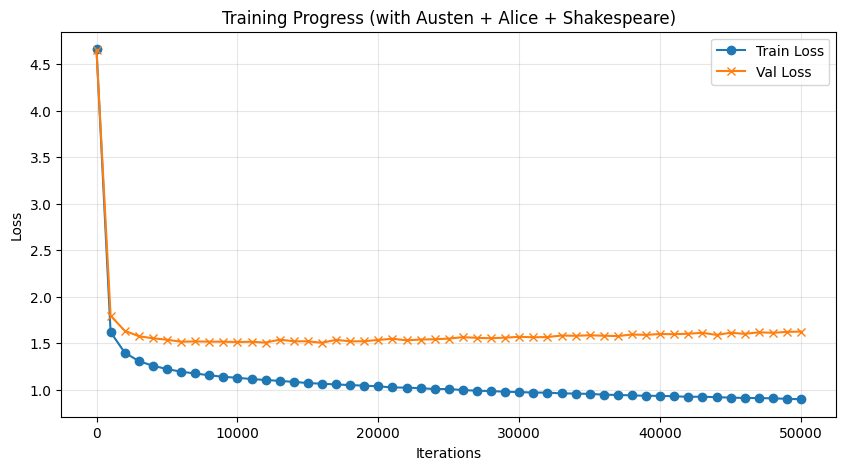


=== GENERATED TEXT ===


RuntimeError: The size of tensor a (128) must match the size of tensor b (6) at non-singleton dimension 2

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
import matplotlib.pyplot as plt

# =====================================================================
# 1. HYPERPARAMETERS
# =====================================================================
batch_size = 64
block_size = 128
n_embd = 192
n_head = 6
n_layer = 6
learning_rate = 5e-4
max_iters = 50000
eval_interval = 1000
dropout = 0.15

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}\n")

# =====================================================================
# 2. LOAD PUBLIC DOMAIN DATASETS
# =====================================================================
print("Loading public domain texts...")

# Tiny Shakespeare
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(shakespeare_url).text

# Jane Austen - Pride and Prejudice
austen_url = "https://www.gutenberg.org/files/1342/1342-0.txt"
text += "\n\n" + requests.get(austen_url).text

# Alice's Adventures in Wonderland
alice_url = "https://www.gutenberg.org/files/11/11-0.txt"
text += "\n\n" + requests.get(alice_url).text

print(f"Total characters: {len(text):,}")

# =====================================================================
# 3. VOCABULARY & DATA PREP
# =====================================================================
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split):
    dataset = train_data if split == 'train' else val_data
    ix = torch.randint(len(dataset) - block_size, (batch_size,))
    x = torch.stack([dataset[i:i+block_size] for i in ix])
    y = torch.stack([dataset[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# =====================================================================
# 4. MODEL ARCHITECTURE
# =====================================================================
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2,-1) * (1.0 / (k.shape[-1]**0.5))
        wei = wei.masked_fill(self.tril == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class TinyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

# =====================================================================
# 5. TRAINING SETUP
# =====================================================================
model = TinyModel().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}\n")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses_history = []
val_losses_history = []
iterations = []

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(100)
        for k in range(100):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

# =====================================================================
# 6. TRAINING LOOP
# =====================================================================
print("Starting training...\n")
for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses_history.append(losses['train'])
        val_losses_history.append(losses['val'])
        iterations.append(iter)
        print(f"Step {iter:5d} | Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

    xb, yb = get_batch('train')
    _, loss = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("\nTraining completed!")

# =====================================================================
# 7. LOSS CURVE
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(iterations, train_losses_history, label='Train Loss', marker='o')
plt.plot(iterations, val_losses_history, label='Val Loss', marker='x')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Progress (with Austen + Alice + Shakespeare)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =====================================================================
# 8. TEXT GENERATION
# =====================================================================
@torch.no_grad()
def generate(prompt="", max_new_tokens=300, temperature=0.8):
    model.eval()
    context = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        context_crop = context[:, -block_size:]
        logits, _ = model(context_crop)
        logits = logits[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        context = torch.cat((context, next_token), dim=1)

    return decode(context[0].tolist())

print("\n=== GENERATED TEXT ===")
print(generate("ROMEO:", max_new_tokens=400))